[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/probability_statistics/05_continuous_distributions/first_principles.ipynb)

# Module 05 — Continuous Distributions

## 1. Why This Module Exists

Once a quantity is measured on a continuum — a waiting time, a position, a voltage, a logit — no single value can carry positive probability. If it did, uncountably many values could not share a total budget of 1. Probability must therefore be *spread*, described by a density $f_X$ whose integrals, not whose values, are probabilities:

$$
P(a \le X \le b) = \int_a^b f_X(t)\,dt, \qquad f_X \ge 0, \qquad \int_{\mathbb{R}} f_X = 1.
$$

This one shift has consequences that trip up newcomers permanently. A density can exceed 1. It carries physical units ($\text{s}^{-1}$ for a waiting-time density). It is *not* invariant under reparameterization: rescaling the axis rescales $f$ by a Jacobian. The CDF $F_X$, by contrast, is dimensionless, bounded in $[0,1]$, and invariant under increasing reparameterizations — which is why every conceptual question about continuous laws is best answered by returning to $F_X$.

The second reason the module exists is that the standard families are not a zoo to be memorized. Each one is the *unique* answer to a sharply posed structural question, and the questions are what make a modeling choice defensible. Sections 4 and 5 state and prove those characterizations; Section 6 checks each of them on numbers small enough to verify by hand; Section 7 turns them into working code.

## 2. Intuition

Continuous families are answers to structural demands, not arbitrary formulas.

- **"A wait with no aging"** — $P(X \gt s+t \mid X \gt s) = P(X \gt t)$ — forces the **Exponential** (Theorem 4.1).
- **"The sum of $k$ independent identical memoryless waits"** forces the **Gamma**$(k, \lambda)$, and $k = 1$ recovers the Exponential (Theorem 4.2).
- **"Maximum uncertainty given a fixed mean and variance"** forces the **Normal** (Theorem 4.4); fixing $E[\lvert X \rvert]$ instead forces the **Laplace**; fixing only a bounded support forces the **Uniform**.
- **"Independent coordinates whose joint law is rotation-invariant"** forces the **Normal** again (Maxwell's theorem, exercise L3.1) — the reason velocities in an ideal gas are Gaussian.
- **"A flexible law on $[0,1]$ conjugate to Bernoulli sampling"** forces the **Beta**, obtained by normalizing two Gammas (Theorem 4.5); its simplex-valued generalization is the **Dirichlet**.
- **"A standard normal divided by an independent root-mean-square of normals"** produces **Student's $t$**, heavy-tailed because the denominator can be small (Theorems 4.6 and 4.7).

### 2.1 The Hazard Rate Is the Fingerprint of a Family

The single most useful diagnostic is the *hazard rate* $h(t) = f(t)/S(t)$, where $S = 1 - F$ is the survival function. It answers "given survival to time $t$, how fast is failure arriving right now?" and, unlike the density, it is directly interpretable and directly estimable from censored data.

Reading a fitted hazard is reading the family: flat means Exponential and no aging; increasing means wear-out; decreasing means infant mortality or a burn-in period; a hump means a risky early phase followed by a settled one. Because $S(x) = \exp\left(-\int_0^x h\right)$ (Definition 3.1), the hazard determines the law completely, so this qualitative picture is a complete classification, not a heuristic.

The next cell is the notebook preamble: plotting defaults, the single seeded generator `rng` used everywhere, and the SciPy entry points needed later.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from math import e, exp, gamma as Gamma_fn, log, pi, sqrt
from scipy import integrate, stats
from scipy.special import beta as beta_fn, erfc, gammaln

print("preamble ready")

preamble ready


**Figure 1 — the hazard panel.** This draws $h(t) = f(t)/S(t)$ for four laws: Exponential (Weibull with $k = 1$), Weibull with $k = 0.5$, Weibull with $k = 2$, and Lognormal. It checks that the four qualitative shapes claimed in Section 2.1 — flat, decreasing, increasing, hump — really are what the formulas produce.

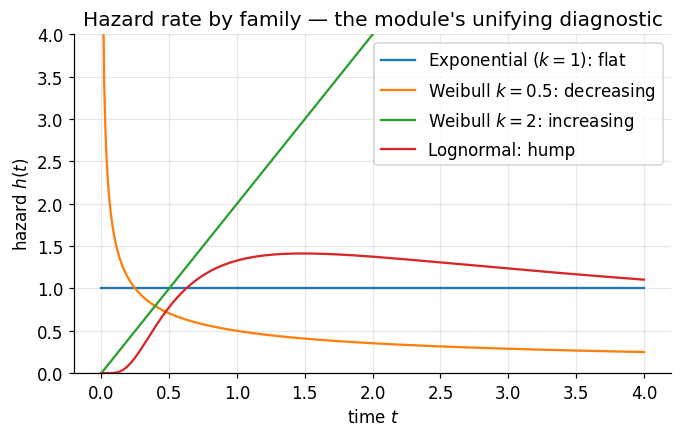

Weibull k=0.5 hazard: 0.7071 -> 0.2673 (decreasing)
Weibull k=2.0 hazard: 1.0000 -> 7.0000 (increasing)
Lognormal hazard peaks at t = 1.484, then falls (hump)


In [2]:
t_grid = np.linspace(1e-3, 4.0, 400)


def weibull_hazard(t, k, lam=1.0):
    return (k / lam) * (t / lam) ** (k - 1)


def lognormal_hazard(t, mu=0.0, sigma=0.6):
    law = stats.lognorm(sigma, scale=np.exp(mu))
    return law.pdf(t) / np.clip(law.sf(t), 1e-300, None)


fig, ax = plt.subplots()
ax.plot(t_grid, np.ones_like(t_grid), label="Exponential ($k=1$): flat")
ax.plot(t_grid, weibull_hazard(t_grid, 0.5), label="Weibull $k=0.5$: decreasing")
ax.plot(t_grid, weibull_hazard(t_grid, 2.0), label="Weibull $k=2$: increasing")
ax.plot(t_grid, lognormal_hazard(t_grid), label="Lognormal: hump")
ax.set_xlabel("time $t$")
ax.set_ylabel("hazard $h(t)$")
ax.set_title("Hazard rate by family — the module's unifying diagnostic")
ax.set_ylim(0, 4)
ax.legend()
plt.show()

lognorm_h = lognormal_hazard(t_grid)
peak = t_grid[int(np.argmax(lognorm_h))]
print(f"Weibull k=0.5 hazard: {weibull_hazard(0.5, 0.5):.4f} -> {weibull_hazard(3.5, 0.5):.4f} (decreasing)")
print(f"Weibull k=2.0 hazard: {weibull_hazard(0.5, 2.0):.4f} -> {weibull_hazard(3.5, 2.0):.4f} (increasing)")
print(f"Lognormal hazard peaks at t = {peak:.3f}, then falls (hump)")

Flat, decreasing, increasing, and non-monotone hazards are visibly distinct, and the printed endpoint values confirm the monotonicity direction in each Weibull case. A fitted hazard that is not flat is by itself proof that the data are not exponential — no goodness-of-fit test required.

## 3. Definitions

### Definition 3.1 (Density, Survival, Hazard)

$X$ is *(absolutely) continuous* if there is a measurable $f_X \ge 0$ with $F_X(x) = \int_{-\infty}^x f_X(t)\,dt$ for every $x$. The *support* is the closure of $\{x : f_X(x) \gt 0\}$. The *survival function* is $S(x) = 1 - F_X(x)$, and where $S(x) \gt 0$ the *hazard rate* is

$$
h(x) = \frac{f_X(x)}{S(x)} = -\frac{d}{dx}\ln S(x), \qquad \text{equivalently} \qquad S(x) = \exp\left(-\int_0^x h(t)\,dt\right)
$$

for laws supported on $[0,\infty)$ with $S(0) = 1$.

### Definition 3.2 (Uniform)

$X \sim \text{Unif}(a,b)$ if $f_X(x) = \frac{1}{b-a}$ on $[a,b]$. Then $E[X] = \frac{a+b}{2}$, $\mathrm{Var}(X) = \frac{(b-a)^2}{12}$, and $F_X(x) = \frac{x-a}{b-a}$ on the support.

### Definition 3.3 (Exponential)

$X \sim \text{Exponential}(\lambda)$ with rate $\lambda \gt 0$ if $f_X(x) = \lambda e^{-\lambda x}$ for $x \ge 0$. Then $S(x) = e^{-\lambda x}$, $h(x) \equiv \lambda$, $E[X] = 1/\lambda$, $\mathrm{Var}(X) = 1/\lambda^2$, and $M_X(t) = \frac{\lambda}{\lambda - t}$ for $t \lt \lambda$.

### Definition 3.4 (Gamma)

$X \sim \text{Gamma}(\alpha, \lambda)$ with shape $\alpha \gt 0$ and rate $\lambda \gt 0$ if

$$
f_X(x) = \frac{\lambda^{\alpha}}{\Gamma(\alpha)}x^{\alpha-1}e^{-\lambda x}, \qquad x \gt 0, \qquad \Gamma(\alpha) = \int_0^{\infty} t^{\alpha-1}e^{-t}\,dt.
$$

Then $E[X] = \alpha/\lambda$, $\mathrm{Var}(X) = \alpha/\lambda^2$, and $M_X(t) = \left(\frac{\lambda}{\lambda-t}\right)^{\alpha}$ for $t \lt \lambda$. Special cases: $\alpha = 1$ is Exponential; $\alpha = k/2$ with $\lambda = 1/2$ is $\chi^2_k$.

### Definition 3.5 (Beta)

$X \sim \text{Beta}(\alpha, \beta)$ if

$$
f_X(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}, \quad 0 \lt x \lt 1, \qquad B(\alpha,\beta) = \int_0^1 w^{\alpha-1}(1-w)^{\beta-1}dw.
$$

Then $E[X] = \frac{\alpha}{\alpha+\beta}$ and $\mathrm{Var}(X) = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$. The shape is unimodal when $\alpha, \beta \gt 1$, uniform when $\alpha = \beta = 1$, and U-shaped when $\alpha, \beta \lt 1$. The identity $B(\alpha,\beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$ is *derived*, not assumed, in Proof 5.5.

### Definition 3.6 (Dirichlet)

For $\alpha_1,\ldots,\alpha_K \gt 0$ and $\alpha_0 = \sum_j \alpha_j$, the vector $\mathbf{X} = (X_1,\ldots,X_K)$ is $\text{Dirichlet}(\alpha_1,\ldots,\alpha_K)$ if it is supported on the simplex $\left\{x_j \ge 0, \sum_j x_j = 1\right\}$ with density, in the free coordinates $x_1,\ldots,x_{K-1}$,

$$
f(x_1,\ldots,x_{K-1}) = \frac{1}{B(\boldsymbol{\alpha})}\prod_{j=1}^{K} x_j^{\alpha_j-1}, \qquad B(\boldsymbol{\alpha}) = \frac{\prod_{j} \Gamma(\alpha_j)}{\Gamma(\alpha_0)}, \qquad x_K = 1 - \sum_{j \lt K} x_j.
$$

Its marginals are $X_j \sim \text{Beta}(\alpha_j, \alpha_0 - \alpha_j)$, so $E[X_j] = \alpha_j/\alpha_0$ and $\mathrm{Var}(X_j) = \frac{\alpha_j(\alpha_0-\alpha_j)}{\alpha_0^2(\alpha_0+1)}$, while $\mathrm{Cov}(X_i,X_j) = -\frac{\alpha_i\alpha_j}{\alpha_0^2(\alpha_0+1)} \lt 0$ for $i \ne j$: mass moved toward one coordinate must leave the others. $K = 2$ recovers the Beta.

### Definition 3.7 (Normal)

$X \sim \mathcal{N}(\mu, \sigma^2)$ if

$$
f_X(x) = \frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right), \qquad x \in \mathbb{R}.
$$

Then $E[X] = \mu$, $\mathrm{Var}(X) = \sigma^2$, and $M_X(t) = \exp\left(\mu t + \tfrac{1}{2}\sigma^2 t^2\right)$ for all $t \in \mathbb{R}$; all cumulants beyond the second vanish. The standard normal CDF is written $\Phi$.

### Definition 3.8 (Laplace, Student, Cauchy, Lognormal, Weibull)

- $\text{Laplace}(\mu, b)$: $f(x) = \frac{1}{2b}e^{-\lvert x-\mu \rvert/b}$, mean $\mu$, variance $2b^2$.
- $t_\nu$: $f(x) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)}\left(1 + \frac{x^2}{\nu}\right)^{-(\nu+1)/2}$; the mean exists iff $\nu \gt 1$ and the variance $\frac{\nu}{\nu-2}$ exists iff $\nu \gt 2$.
- Cauchy $= t_1$: $f(x) = \frac{1}{\pi(1+x^2)}$; no mean and no MGF, but characteristic function $e^{-\lvert t \rvert}$.
- $\text{Lognormal}(\mu,\sigma^2)$: $X = e^{Y}$ with $Y \sim \mathcal{N}(\mu,\sigma^2)$, so $f(x) = \frac{1}{x\sigma\sqrt{2\pi}}e^{-(\ln x - \mu)^2/(2\sigma^2)}$, $E[X] = e^{\mu + \sigma^2/2}$, and $E\left[e^{tX}\right] = \infty$ for every $t \gt 0$.
- $\text{Weibull}(k, \lambda)$: $S(x) = e^{-(x/\lambda)^k}$, hazard $h(x) = \frac{k}{\lambda}\left(\frac{x}{\lambda}\right)^{k-1}$, increasing for $k \gt 1$ and decreasing for $k \lt 1$.

### Definition 3.9 (Differential Entropy)

For a density $f$ on $\mathbb{R}$ with $\int f \lvert \ln f \rvert \lt \infty$,

$$
H(f) = -\int_{\mathbb{R}} f(x)\ln f(x)\,dx .
$$

Because $h$ is reserved for the hazard rate throughout this module, differential entropy is written $H$ with a *density* argument. Unlike discrete entropy it may be negative and it is not invariant under reparameterization.

### Reference Table of Canonical Continuous Families

| Family | Density (support) | Mean | Variance | Structural characterization |
|---|---|---|---|---|
| Uniform($a,b$) | $\frac{1}{b-a}$ on $[a,b]$ | $\frac{a+b}{2}$ | $\frac{(b-a)^2}{12}$ | Max entropy on a bounded interval |
| Exponential($\lambda$) | $\lambda e^{-\lambda x}$, $x \gt 0$ | $\frac{1}{\lambda}$ | $\frac{1}{\lambda^2}$ | Unique memoryless / constant hazard |
| Gamma($\alpha,\lambda$) | $\frac{\lambda^\alpha}{\Gamma(\alpha)}x^{\alpha-1}e^{-\lambda x}$ | $\frac{\alpha}{\lambda}$ | $\frac{\alpha}{\lambda^2}$ | Sum of $\alpha$ exponentials (integer $\alpha$) |
| Normal($\mu,\sigma^2$) | $\frac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/(2\sigma^2)}$ | $\mu$ | $\sigma^2$ | CLT limit; max entropy at fixed variance |
| Beta($\alpha,\beta$) | $\frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}$ | $\frac{\alpha}{\alpha+\beta}$ | $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$ | Conjugate to Bernoulli; Gamma ratio |
| Dirichlet($\boldsymbol{\alpha}$) | $\frac{1}{B(\boldsymbol{\alpha})}\prod_j x_j^{\alpha_j-1}$ on the simplex | $\frac{\alpha_j}{\alpha_0}$ | $\frac{\alpha_j(\alpha_0-\alpha_j)}{\alpha_0^2(\alpha_0+1)}$ | Normalized independent Gammas |
| Chi-square($k$) | $\text{Gamma}(k/2,\ 1/2)$ | $k$ | $2k$ | Sum of $k$ squared standard normals |
| $F(m,n)$ | $\frac{(m/n)^{m/2}}{B(m/2,n/2)}\frac{x^{m/2-1}}{(1+mx/n)^{(m+n)/2}}$, $x \gt 0$ | $\frac{n}{n-2}$ ($n \gt 2$) | $\frac{2n^2(m+n-2)}{m(n-2)^2(n-4)}$ ($n \gt 4$) | Ratio of independent scaled $\chi^2$ |
| Student($\nu$) | $\frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\Gamma\left(\frac{\nu}{2}\right)}\left(1+\frac{x^2}{\nu}\right)^{-(\nu+1)/2}$ | $0$ if $\nu \gt 1$ | $\frac{\nu}{\nu-2}$ if $\nu \gt 2$ | Normal scale-mixed by a Gamma precision |
| Laplace($\mu,b$) | $\frac{1}{2b}e^{-\lvert x-\mu \rvert/b}$ | $\mu$ | $2b^2$ | Max entropy at fixed $E\lvert X-\mu \rvert$ |
| Lognormal($\mu,\sigma^2$) | $\frac{1}{x\sigma\sqrt{2\pi}}e^{-(\ln x-\mu)^2/(2\sigma^2)}$ | $e^{\mu+\sigma^2/2}$ | $\left(e^{\sigma^2}-1\right)e^{2\mu+\sigma^2}$ | Multiplicative CLT |
| Weibull($k,\lambda$) | $\frac{k}{\lambda}\left(\frac{x}{\lambda}\right)^{k-1}e^{-(x/\lambda)^k}$ | $\lambda\Gamma\left(1+\frac{1}{k}\right)$ | $\lambda^2\left[\Gamma\left(1+\frac{2}{k}\right) - \Gamma\left(1+\frac{1}{k}\right)^2\right]$ | Power-law hazard |

## 4. Main Results

### Theorem 4.1 (Memorylessness characterizes the Exponential)

Let $X$ be a random variable with values in $(0,\infty)$ whose survival function $S(x) = P(X \gt x)$ is right-continuous, satisfies $S(0) = 1$, and satisfies $S(t_1) \lt 1$ for at least one $t_1 \gt 0$. Then

$$
P(X \gt s+t \mid X \gt s) = P(X \gt t) \quad \text{for all } s,t \ge 0 \qquad \Longleftrightarrow \qquad X \sim \text{Exponential}(\lambda) \text{ for some } \lambda \gt 0 .
$$

*Why each hypothesis is needed.* Right-continuity is what upgrades the solution of the Cauchy equation from the rationals to the reals; without some regularity the equation admits pathological non-measurable solutions. $S(0) = 1$ fixes the support at $(0,\infty)$ and rules out an atom at the origin. The non-degeneracy $S(t_1) \lt 1$ excludes $S \equiv 1$, that is $X = +\infty$ almost surely, which satisfies the functional equation but is not a real-valued random variable; it is exactly what forces $\lambda \gt 0$ rather than $\lambda \ge 0$.

$$
\boxed{h(x) \equiv \lambda \iff S(x) = e^{-\lambda x} \iff X \text{ is memoryless}}
$$

**Interpretation.** Constant hazard, exponential survival, and memorylessness are three names for one object: a process that makes no progress toward its own event. The consequence for modeling is blunt — the moment a fitted hazard curve bends, the exponential model is refuted, and reliability, queueing, and survival analysis must move to Weibull or Gamma.

### Theorem 4.2 (Gamma additivity at a common rate)

Let $X_1,\ldots,X_r$ be independent with $X_i \sim \text{Gamma}(\alpha_i, \lambda)$, **all sharing the same rate $\lambda$**. Then $\sum_{i} X_i \sim \text{Gamma}\left(\sum_i \alpha_i, \lambda\right)$. In particular $k$ i.i.d. $\text{Exponential}(\lambda)$ waits sum to $\text{Gamma}(k,\lambda)$, the Erlang law.

*Why each hypothesis is needed.* Independence is what turns the MGF of the sum into a product. The common rate is what makes that product collapse to a single power $\left(\frac{\lambda}{\lambda-t}\right)^{\sum_i\alpha_i}$; with unequal rates the product is a different function altogether and the sum is hypoexponential, not Gamma — this failure is exhibited numerically in Section 7.

$$
\boxed{\text{Gamma}(\alpha_1,\lambda) + \text{Gamma}(\alpha_2,\lambda) = \text{Gamma}(\alpha_1+\alpha_2,\lambda) \quad (\text{independent, common } \lambda)}
$$

**Interpretation.** Shape is additive and rate is a unit of time, so a Gamma is a "how many stages" parameter plus a clock. The consequence is the Erlang–Poisson duality: $P(S_k \gt t) = P(N(t) \lt k)$ ties the continuous waiting time to the discrete count and gives the Erlang tail as a truncated Poisson sum.

### Theorem 4.3 (Gaussian normalization, MGF and moments)

$\int_{-\infty}^{\infty}e^{-x^2/2}\,dx = \sqrt{2\pi}$; consequently Definition 3.7 defines a density, and $Z \sim \mathcal{N}(0,1)$ has $M_Z(t) = e^{t^2/2}$ for every real $t$, with

$$
E\left[Z^{2m+1}\right] = 0, \qquad E\left[Z^{2m}\right] = (2m-1)!! = \frac{(2m)!}{2^{m}m!}.
$$

*Why the hypotheses are mild.* Nothing is assumed beyond the definition; the MGF exists for all $t$ because $e^{tz - z^2/2}$ is integrable for every $t$, which is precisely what fails for the Lognormal and the Student $t$.

### Theorem 4.4 (The Normal maximizes entropy at fixed variance)

Among all densities $f$ on $\mathbb{R}$ with $\int x f(x)\,dx = \mu$ and $\int (x-\mu)^2 f(x)\,dx = \sigma^2 \lt \infty$, the differential entropy of Definition 3.9 satisfies

$$
\boxed{H(f) \le \tfrac{1}{2}\ln\left(2\pi e\sigma^2\right) = H\left(\varphi_{\mu,\sigma^2}\right), \quad \text{with equality iff } f = \varphi_{\mu,\sigma^2} \text{ almost everywhere}}
$$

where $\varphi_{\mu,\sigma^2}$ is the $\mathcal{N}(\mu,\sigma^2)$ density.

**Interpretation.** The Gaussian is the least committal law once a variance is named: every other density with the same variance encodes *additional* structure, and the entropy gap $H(\varphi) - H(f)$ is exactly $D_{\mathrm{KL}}\left(f \parallel \varphi\right)$, a measurable amount of smuggled-in assumption. The consequence is the honest defense of Gaussian noise models — not that errors are truly Gaussian, but that assuming anything else asserts more than the data support.

*Why each hypothesis is needed.* A finite variance is essential: the constraint set must be non-empty and the reference Gaussian must exist, which is why no maximum-entropy Gaussian competes with the Cauchy. The mean constraint only fixes the centering; without it the same bound holds with $\sigma^2$ replaced by the second moment.

### Theorem 4.5 (Gamma to Beta, and independence of ratio and total)

Let $U \sim \text{Gamma}(\alpha,\lambda)$ and $V \sim \text{Gamma}(\beta,\lambda)$ be independent with a **common rate**. Then

$$
\boxed{W = \frac{U}{U+V} \sim \text{Beta}(\alpha,\beta), \qquad T = U+V \sim \text{Gamma}(\alpha+\beta,\lambda), \qquad W \perp T}
$$

**Interpretation.** The *proportion* and the *total* of two independent Gammas carry disjoint information: knowing the total tells you nothing about the split. The consequence is algorithmic — Beta and Dirichlet variates are generated by drawing independent Gammas and normalizing, and the normalizing step provably costs no information about the sum.

*Why each hypothesis is needed.* Independence and the common rate are what make the joint density factor into a $w$-part and a $t$-part; with unequal rates the exponential factor is $e^{-\lambda_1 wt - \lambda_2(1-w)t}$, which does not separate, and both the Beta marginal and the independence fail.

### Theorem 4.6 (Student's $t$ as a Gaussian scale mixture)

If $X \mid \tau \sim \mathcal{N}(0, 1/\tau)$ with precision $\tau \sim \text{Gamma}\left(\frac{\nu}{2}, \frac{\nu}{2}\right)$, then marginally $X \sim t_\nu$, and $f_{t_\nu}(x) \sim c_\nu \lvert x \rvert^{-(\nu+1)}$ as $\lvert x \rvert \to \infty$, so $E\left[\lvert X \rvert^{p}\right] \lt \infty$ if and only if $p \lt \nu$.

*Why each hypothesis is needed.* The mixing law must be Gamma with the two shape and rate parameters tied to $\nu/2$; any other mixing law produces a different scale mixture, and the tie is what makes the resulting scale have mean one degree of freedom per unit of $\nu$. Independence of $\tau$ from the conditional Gaussian is implicit in the hierarchical statement.

### Theorem 4.7 (Derived sampling laws)

Let $Z, Z_1,\ldots,Z_k$ be i.i.d. $\mathcal{N}(0,1)$ and mutually independent. Then $\sum_{i=1}^k Z_i^2 \sim \chi^2_k = \text{Gamma}(k/2, 1/2)$; if $Z$ is independent of that sum,

$$
T = \frac{Z}{\sqrt{\frac{1}{k}\sum_{i=1}^k Z_i^2}} \sim t_k,
$$

and if $A \sim \chi^2_m$ and $B \sim \chi^2_n$ are independent, then $X = \frac{A/m}{B/n} \sim F_{m,n}$ with density and mean

$$
\boxed{f_{F_{m,n}}(x) = \frac{(m/n)^{m/2}}{B(m/2,n/2)}\cdot\frac{x^{m/2-1}}{\left(1+\frac{m}{n}x\right)^{(m+n)/2}},\quad x \gt 0, \qquad E[X] = \frac{n}{n-2}\ \ (n \gt 2)}
$$

**Interpretation.** Every classical test statistic is one of these three shapes, and each is built from the same raw material by Theorems 4.2 and 4.5. The consequence is that $F$ needs no separate theory: it is the Beta of Theorem 4.5 pushed through the increasing map $w \mapsto \frac{n}{m}\frac{w}{1-w}$, which is why its mean $\frac{n}{n-2}$ depends only on the denominator degrees of freedom.

*Why each hypothesis is needed.* Independence of numerator and denominator is what makes $T$ a $t$ and $X$ an $F$; without it the ratio has no standard law. Normality of the $Z_i$ is what makes the sum of squares a Gamma with rate $1/2$.

### Summary of the Main Identities

| Object | Formula | Hypotheses |
|---|---|---|
| Hazard and survival | $h = f/S$, $S(x) = \exp\left(-\int_0^x h\right)$ | $S \gt 0$ on the support |
| Memorylessness | $S(x) = e^{-\lambda x}$, $h \equiv \lambda$ | Theorem 4.1 |
| Gamma additivity | $\text{Gamma}(\alpha_1,\lambda) + \text{Gamma}(\alpha_2,\lambda) = \text{Gamma}(\alpha_1+\alpha_2,\lambda)$ | independent, common rate |
| Gaussian MGF | $M(t) = \exp\left(\mu t + \tfrac{1}{2}\sigma^2 t^2\right)$ | all $t$; Theorem 4.3 |
| Gaussian moments | $E\left[Z^{2m}\right] = (2m-1)!!$ | $Z \sim \mathcal{N}(0,1)$ |
| Maximum entropy | $H(f) \le \tfrac{1}{2}\ln\left(2\pi e\sigma^2\right)$ | fixed mean and finite variance |
| Gamma to Beta | $\frac{U}{U+V} \sim \text{Beta}(\alpha,\beta) \perp U+V$ | independent, common rate |
| Student tail | $f(x) \sim c\lvert x \rvert^{-(\nu+1)}$, $E\lvert X\rvert^p \lt \infty \iff p \lt \nu$ | Theorem 4.6 |
| Chi-square | $\sum_{i=1}^k Z_i^2 \sim \chi^2_k$, mean $k$, variance $2k$ | i.i.d. standard normal |
| Change of variables | $f_Y(y) = f_X\left(g^{-1}(y)\right)\left\lvert \frac{d g^{-1}}{dy} \right\rvert$ | $g$ strictly monotone, differentiable |

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Write $S(x) = P(X \gt x)$. Conditioning gives $P(X \gt s+t \mid X \gt s) = S(s+t)/S(s)$ whenever $S(s) \gt 0$, so the memoryless hypothesis is the multiplicative Cauchy equation $S(s+t) = S(s)S(t)$ for all $s,t \ge 0$.

*Step 1 — positivity.* Suppose $S(t_0) = 0$ for some $t_0 \gt 0$. Then $S(t_0) = S(t_0/2)^2 = 0$ forces $S(t_0/2) = 0$, and iterating gives $S(t_0/2^n) = 0$ for every $n$. Right-continuity at $0$ then gives $S(0) = \lim_n S(t_0/2^n) = 0$, contradicting $S(0) = 1$. Hence $S \gt 0$ everywhere and $g(t) = \ln S(t)$ is well defined and finite.

*Step 2 — additive Cauchy equation on the rationals.* The hypothesis becomes $g(s+t) = g(s) + g(t)$ with $g(0) = 0$. Induction gives $g(n) = n\,g(1)$ for integers $n \ge 1$; applying the same identity to $n$ copies of $1/n$ gives $g(1) = n\,g(1/n)$, hence $g(1/n) = g(1)/n$; combining, $g(m/n) = (m/n)\,g(1)$ for every positive rational.

*Step 3 — extend to the reals.* $S$ is non-increasing, so $g$ is non-increasing, and $g$ agrees with the linear function $t \mapsto t\,g(1)$ on the dense set $\mathbb{Q}_{\ge 0}$. A monotone function agreeing with a continuous monotone function on a dense set agrees with it everywhere: for real $t$, take rationals $q_n \uparrow t$ and $r_n \downarrow t$, so $r_n g(1) \le g(t) \le q_n g(1)$, and both bounds converge to $t\,g(1)$.

*Step 4 — sign of the constant.* By hypothesis $S(t_1) \lt 1$ for some $t_1 \gt 0$, so $g(t_1) \lt 0$ and therefore $g(1) \lt 0$. Set $\lambda = -g(1) \gt 0$. Then

$$
S(t) = e^{-\lambda t}, \qquad F(t) = 1 - e^{-\lambda t}, \qquad f(t) = \lambda e^{-\lambda t},
$$

which is $\text{Exponential}(\lambda)$. The converse is a one-line computation: for the exponential, $S(s+t)/S(s) = e^{-\lambda t} = S(t)$. $\blacksquare$

**Hazard reading.** Differentiating, $h(t) = -\frac{d}{dt}\ln S(t) = \lambda$, so memorylessness is *exactly* constant hazard. Any law with a non-constant hazard therefore fails the functional equation, which is what the panel drawn in Section 2 displays.

### Proof 5.2 (of Theorem 4.2)

*MGF computation.* For $X \sim \text{Gamma}(\alpha,\lambda)$ and $t \lt \lambda$, substituting $u = (\lambda - t)x$,

$$
M_X(t) = \int_0^{\infty}e^{tx}\frac{\lambda^{\alpha}}{\Gamma(\alpha)}x^{\alpha-1}e^{-\lambda x}dx = \frac{\lambda^{\alpha}}{\Gamma(\alpha)}\int_0^{\infty}x^{\alpha-1}e^{-(\lambda-t)x}dx = \frac{\lambda^{\alpha}}{(\lambda-t)^{\alpha}} = \left(\frac{\lambda}{\lambda-t}\right)^{\alpha},
$$

using $\int_0^\infty x^{\alpha-1}e^{-cx}dx = \Gamma(\alpha)c^{-\alpha}$ for $c \gt 0$.

*Sum.* Independence gives $M_{\sum_i X_i}(t) = \prod_i M_{X_i}(t) = \prod_i\left(\frac{\lambda}{\lambda-t}\right)^{\alpha_i} = \left(\frac{\lambda}{\lambda-t}\right)^{\sum_i \alpha_i}$ on the common interval $t \lt \lambda$. This is the MGF of $\text{Gamma}\left(\sum_i\alpha_i, \lambda\right)$, and an MGF finite on an open interval containing $0$ determines the law uniquely, so the sum has that distribution. $\blacksquare$

**Direct confirmation for $k = 2$ exponentials.** Convolving,

$$
f_{S_2}(s) = \int_0^s \lambda e^{-\lambda u}\,\lambda e^{-\lambda(s-u)}\,du = \lambda^2 e^{-\lambda s}\int_0^s du = \lambda^2 s\,e^{-\lambda s},
$$

which is the $\text{Gamma}(2,\lambda)$ density.

**Where the common rate enters.** With rates $\lambda_1 \ne \lambda_2$ the product is $\left(\frac{\lambda_1}{\lambda_1-t}\right)^{\alpha_1}\left(\frac{\lambda_2}{\lambda_2-t}\right)^{\alpha_2}$, which has two distinct poles and is therefore not the MGF of any Gamma. The resulting law is hypoexponential; this is the exact continuous analogue of the closure condition for the Binomial in [Module 04](../04_discrete_distributions/).

**Poisson duality.** For integer $k$, $S_k$ is the time of the $k$-th arrival in a Poisson process of rate $\lambda$, so $\{S_k \gt t\} = \{N(t) \lt k\}$ and

$$
P(S_k \gt t) = \sum_{j=0}^{k-1}\frac{(\lambda t)^j e^{-\lambda t}}{j!}.
$$

### Proof 5.3 (of Theorem 4.3)

*Normalization by the polar trick.* Let $I = \int_{\mathbb{R}}e^{-x^2/2}dx$, a finite positive number since the integrand is bounded by $e^{-\lvert x \rvert/2 + 1/2}$ outside $[-1,1]$. Then by Tonelli's theorem and the substitution $(x,y) = (r\cos\theta, r\sin\theta)$ with area element $r\,dr\,d\theta$,

$$
I^2 = \int_{\mathbb{R}}\int_{\mathbb{R}}e^{-(x^2+y^2)/2}dx\,dy = \int_0^{2\pi}\!\!\int_0^{\infty}e^{-r^2/2}\,r\,dr\,d\theta = 2\pi\left[-e^{-r^2/2}\right]_0^{\infty} = 2\pi ,
$$

so $I = \sqrt{2\pi}$. The Jacobian factor $r$ is what makes the radial integral elementary.

*MGF by completing the square.* For every real $t$,

$$
M_Z(t) = \frac{1}{\sqrt{2\pi}}\int_{\mathbb{R}} e^{tz}e^{-z^2/2}dz = \frac{e^{t^2/2}}{\sqrt{2\pi}}\int_{\mathbb{R}} e^{-(z-t)^2/2}dz = e^{t^2/2},
$$

because $tz - \frac{z^2}{2} = \frac{t^2}{2} - \frac{(z-t)^2}{2}$ and the shifted integral is again $\sqrt{2\pi}$.

*Moments by matching series.* Expanding $e^{t^2/2} = \sum_{m\ge0}\frac{t^{2m}}{2^m m!}$ and comparing with $M_Z(t) = \sum_{n \ge 0}\frac{E[Z^n]}{n!}t^n$ term by term: all odd coefficients vanish, so $E\left[Z^{2m+1}\right] = 0$, and

$$
\frac{E\left[Z^{2m}\right]}{(2m)!} = \frac{1}{2^{m}m!} \implies E\left[Z^{2m}\right] = \frac{(2m)!}{2^{m}m!} = (2m-1)!! . \qquad \blacksquare
$$

In particular $E[Z^2] = 1$, $E[Z^4] = 3$ — the kurtosis benchmark against which "heavy tailed" is defined — and $E[Z^6] = 15$.

### Proof 5.4 (of Theorem 4.4)

Let $\varphi = \varphi_{\mu,\sigma^2}$ and let $f$ be any density with mean $\mu$ and variance $\sigma^2$. Kullback–Leibler divergence is non-negative, with equality only when the two densities agree almost everywhere, and

$$
0 \le D_{\mathrm{KL}}\left(f \parallel \varphi\right) = \int f \ln\frac{f}{\varphi} = -H(f) - \int f\ln\varphi .
$$

The second term is where the constraints do their work. Since $\ln\varphi(x) = -\frac{1}{2}\ln\left(2\pi\sigma^2\right) - \frac{(x-\mu)^2}{2\sigma^2}$ is a *quadratic polynomial*, its integral against $f$ uses only the first two moments of $f$, which are pinned by hypothesis:

$$
-\int f \ln\varphi = \frac{1}{2}\ln\left(2\pi\sigma^2\right) + \frac{1}{2\sigma^2}\int (x-\mu)^2 f(x)\,dx = \frac{1}{2}\ln\left(2\pi\sigma^2\right) + \frac{1}{2} = \frac{1}{2}\ln\left(2\pi e \sigma^2\right).
$$

Substituting, $0 \le -H(f) + \frac{1}{2}\ln\left(2\pi e\sigma^2\right)$, that is $H(f) \le \frac{1}{2}\ln\left(2\pi e\sigma^2\right)$. Taking $f = \varphi$ makes the divergence zero, so the bound is attained and equals $H(\varphi)$; and equality forces $D_{\mathrm{KL}}\left(f\parallel\varphi\right) = 0$, hence $f = \varphi$ almost everywhere. $\blacksquare$

**The gap is a divergence.** Rearranging gives $H(\varphi) - H(f) = D_{\mathrm{KL}}\left(f \parallel \varphi\right)$ exactly. The same argument with a different exponential-family reference shows the Laplace maximizes entropy at fixed $E\lvert X-\mu\rvert$ and the Exponential maximizes it on $(0,\infty)$ at fixed mean; exercise L3.3 runs the general version.

### Proof 5.5 (of Theorem 4.5)

Apply the change of variables $(u,v) \mapsto (w,t) = \left(\frac{u}{u+v},\, u+v\right)$, a bijection from $(0,\infty)^2$ onto $(0,1)\times(0,\infty)$ with inverse $u = wt$, $v = (1-w)t$. Its Jacobian is

$$
\left\lvert \det\begin{pmatrix} \partial u/\partial w & \partial u/\partial t \\ \partial v/\partial w & \partial v/\partial t\end{pmatrix}\right\rvert = \left\lvert \det\begin{pmatrix} t & w \\ -t & 1-w\end{pmatrix}\right\rvert = \left\lvert t(1-w) + tw\right\rvert = t .
$$

Therefore $f_{W,T}(w,t) = f_{U,V}(wt, (1-w)t)\cdot t$, and by independence $f_{U,V} = f_U f_V$:

$$
f_{W,T}(w,t) = \frac{\lambda^{\alpha}}{\Gamma(\alpha)}(wt)^{\alpha-1}e^{-\lambda wt}\cdot\frac{\lambda^{\beta}}{\Gamma(\beta)}\left((1-w)t\right)^{\beta-1}e^{-\lambda(1-w)t}\cdot t .
$$

The two exponentials merge into $e^{-\lambda t}$ because $wt + (1-w)t = t$, and the powers of $t$ collect into $t^{\alpha+\beta-1}$. Hence

$$
f_{W,T}(w,t) = \frac{\lambda^{\alpha+\beta}}{\Gamma(\alpha)\Gamma(\beta)}\,w^{\alpha-1}(1-w)^{\beta-1}\,t^{\alpha+\beta-1}e^{-\lambda t},
$$

a product of a function of $w$ alone and a function of $t$ alone. Factorization of a joint density is equivalent to independence, so $W \perp T$. Integrating out $w$ over $(0,1)$ leaves a multiple of $t^{\alpha+\beta-1}e^{-\lambda t}$, which normalizes to $\text{Gamma}(\alpha+\beta,\lambda)$; integrating out $t$ leaves a multiple of $w^{\alpha-1}(1-w)^{\beta-1}$, which normalizes to $\text{Beta}(\alpha,\beta)$. $\blacksquare$

**Corollary (the Beta integral).** Matching the two normalizers in the displayed factorization, $\frac{\lambda^{\alpha+\beta}}{\Gamma(\alpha)\Gamma(\beta)} = \frac{1}{B(\alpha,\beta)}\cdot\frac{\lambda^{\alpha+\beta}}{\Gamma(\alpha+\beta)}$, that is

$$
B(\alpha,\beta) = \int_0^1 w^{\alpha-1}(1-w)^{\beta-1}dw = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)} .
$$

So Definition 3.5's normalizer is a theorem, not a convention.

**Corollary (Dirichlet by normalization).** The same computation in $K$ coordinates, with the map $\left(g_1,\ldots,g_K\right)\mapsto\left(g_1/t,\ldots,g_{K-1}/t,\ t\right)$ where $t = \sum_j g_j$, shows that for independent $G_j \sim \text{Gamma}(\alpha_j,\lambda)$ the vector $\left(G_1/t,\ldots,G_K/t\right)$ is $\text{Dirichlet}(\alpha_1,\ldots,\alpha_K)$ and is independent of $t \sim \text{Gamma}(\alpha_0,\lambda)$.

### Proof 5.6 (of Theorem 4.6)

Integrate the precision out of the hierarchy. With $X \mid \tau \sim \mathcal{N}(0,1/\tau)$ and $\tau \sim \text{Gamma}(\nu/2, \nu/2)$,

$$
f_X(x) = \int_0^{\infty}\sqrt{\frac{\tau}{2\pi}}\,e^{-\tau x^2/2}\cdot\frac{(\nu/2)^{\nu/2}}{\Gamma(\nu/2)}\,\tau^{\nu/2-1}e^{-\nu\tau/2}\,d\tau .
$$

Collect the powers of $\tau$ and the exponentials: the integrand is $\frac{(\nu/2)^{\nu/2}}{\sqrt{2\pi}\,\Gamma(\nu/2)}\,\tau^{\frac{\nu+1}{2}-1}e^{-\tau\frac{x^2+\nu}{2}}$, an unnormalized $\text{Gamma}\left(\frac{\nu+1}{2}, \frac{x^2+\nu}{2}\right)$ density. Using $\int_0^\infty \tau^{a-1}e^{-b\tau}d\tau = \Gamma(a)b^{-a}$ with $a = \frac{\nu+1}{2}$ and $b = \frac{x^2+\nu}{2}$,

$$
f_X(x) = \frac{(\nu/2)^{\nu/2}\,\Gamma\!\left(\frac{\nu+1}{2}\right)}{\sqrt{2\pi}\,\Gamma(\nu/2)}\left(\frac{x^2+\nu}{2}\right)^{-\frac{\nu+1}{2}} = \frac{\Gamma\!\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\!\left(\frac{\nu}{2}\right)}\left(1+\frac{x^2}{\nu}\right)^{-\frac{\nu+1}{2}},
$$

after pulling $\nu^{-\frac{\nu+1}{2}}\cdot 2^{\frac{\nu+1}{2}}\cdot 2^{-\nu/2} \cdot (2\pi)^{-1/2}$ through; this is the $t_\nu$ density of Definition 3.8.

*Tail exponent and moments.* As $\lvert x\rvert \to \infty$, $\left(1 + x^2/\nu\right)^{-\frac{\nu+1}{2}} = \nu^{\frac{\nu+1}{2}}\lvert x\rvert^{-(\nu+1)}\left(1+o(1)\right)$, so $f(x) \sim c_\nu\lvert x\rvert^{-(\nu+1)}$. Hence $\int^{\infty}\lvert x\rvert^{p}f(x)\,dx$ behaves like $\int^{\infty}x^{p-\nu-1}dx$, which converges if and only if $p - \nu - 1 \lt -1$, that is $p \lt \nu$. $\blacksquare$

**Robustness mechanism.** The $t$ negative log-likelihood of a residual $r$ is $\frac{\nu+1}{2}\ln\left(1+\frac{r^2}{\nu}\right)$, which grows logarithmically instead of quadratically; its derivative is bounded and decays to $0$, so a gross outlier is explained by a small sampled precision rather than by dragging the fit.

### Proof 5.7 (of Theorem 4.7)

*Chi-square.* For $Z \sim \mathcal{N}(0,1)$ and $y \gt 0$, $P(Z^2 \le y) = 2\Phi(\sqrt{y}) - 1$, so differentiating,

$$
f_{Z^2}(y) = \frac{1}{\sqrt{y}}\varphi(\sqrt{y}) = \frac{1}{\sqrt{2\pi}}y^{-1/2}e^{-y/2} = \frac{(1/2)^{1/2}}{\Gamma(1/2)}y^{1/2-1}e^{-y/2},
$$

using $\Gamma(1/2) = \sqrt{\pi}$; this is $\text{Gamma}(1/2, 1/2) = \chi^2_1$. Independent squares therefore share the rate $1/2$, so Theorem 4.2 gives $\sum_{i=1}^k Z_i^2 \sim \text{Gamma}(k/2, 1/2) = \chi^2_k$.

*Student.* Put $Q = \frac{1}{k}\sum_{i=1}^k Z_i^2$, so $\tau := Q \sim \text{Gamma}(k/2, k/2)$ by the scaling rule $c\,\text{Gamma}(\alpha,\lambda) = \text{Gamma}(\alpha, \lambda/c)$ applied with $c = 1/k$. Conditionally on $\tau$, the ratio $T = Z/\sqrt{\tau}$ is $\mathcal{N}(0, 1/\tau)$ because $Z$ is independent of $\tau$ and scaling a normal scales its standard deviation. That is exactly the hierarchy of Theorem 4.6 with $\nu = k$, so $T \sim t_k$ by Proof 5.6.

*Fisher's $F$.* Write $A \sim \chi^2_m = \text{Gamma}(m/2, 1/2)$ and $B \sim \chi^2_n = \text{Gamma}(n/2, 1/2)$, independent with a common rate. By Theorem 4.5, $W = \frac{A}{A+B} \sim \text{Beta}(m/2, n/2)$. The statistic is a function of $W$ alone:

$$
X = \frac{A/m}{B/n} = \frac{n}{m}\cdot\frac{A}{B} = \frac{n}{m}\cdot\frac{W}{1-W},
$$

and $w \mapsto x = \frac{n}{m}\frac{w}{1-w}$ is a strictly increasing bijection of $(0,1)$ onto $(0,\infty)$ with inverse $w = \frac{(m/n)x}{1+(m/n)x}$ and derivative $\frac{dw}{dx} = \frac{m/n}{\left(1+(m/n)x\right)^{2}}$. Substituting into the Beta density and writing $\rho = m/n$,

$$
f_X(x) = \frac{1}{B(m/2,n/2)}\left(\frac{\rho x}{1+\rho x}\right)^{\frac{m}{2}-1}\left(\frac{1}{1+\rho x}\right)^{\frac{n}{2}-1}\frac{\rho}{(1+\rho x)^{2}} = \frac{\rho^{m/2}}{B(m/2,n/2)}\cdot\frac{x^{m/2-1}}{(1+\rho x)^{(m+n)/2}} ,
$$

which is the boxed density of Theorem 4.7.

*Mean.* $E[X] = \frac{n}{m}E\left[\frac{A}{B}\right] = \frac{n}{m}E[A]\,E\left[B^{-1}\right]$ by independence. Here $E[A] = m$ and, for $n \gt 2$,

$$
E\left[B^{-1}\right] = \frac{(1/2)^{n/2}}{\Gamma(n/2)}\int_0^{\infty}b^{n/2-2}e^{-b/2}db = \frac{(1/2)^{n/2}\Gamma\left(\frac{n}{2}-1\right)}{\Gamma(n/2)\,(1/2)^{n/2-1}} = \frac{1}{n-2},
$$

using $\Gamma(n/2) = \left(\frac{n}{2}-1\right)\Gamma\left(\frac{n}{2}-1\right)$. Hence $E[X] = \frac{n}{m}\cdot m\cdot\frac{1}{n-2} = \frac{n}{n-2}$; the integral diverges for $n \le 2$, which is why the hypothesis $n \gt 2$ cannot be dropped. $\blacksquare$

## 6. Worked Examples

Every example below is computed by hand on numbers small enough to check, then recomputed in code that asserts agreement.

### Example 6.1 (of Theorem 4.1) — a memoryless wait, and a wait that is not

Buses arrive with $\text{Exponential}(\lambda)$ gaps of mean $10$ minutes, so $\lambda = 1/10$ and $S(t) = e^{-t/10}$. You have waited $15$ minutes.

$$
P(X \gt 25 \mid X \gt 15) = \frac{S(25)}{S(15)} = \frac{e^{-2.5}}{e^{-1.5}} = e^{-1} = 0.3678794 ,
$$

and the residual mean is $E[X - 15 \mid X \gt 15] = 1/\lambda = 10$ minutes: the elapsed quarter hour is informationally worthless. The hazard is $h(t) = \frac{(1/10)e^{-t/10}}{e^{-t/10}} = 0.1$ for every $t$, matching Proof 5.1.

Now replace the exponential by a $\text{Weibull}(k = 2, \lambda_W)$ with the *same* mean $10$. From the reference table, the mean is $\lambda_W\Gamma\left(1+\tfrac12\right) = \lambda_W\frac{\sqrt{\pi}}{2}$, so $\lambda_W = \frac{20}{\sqrt{\pi}}$ and $\lambda_W^2 = \frac{400}{\pi}$. Then

$$
P(X \gt 25 \mid X \gt 15) = \frac{e^{-(25/\lambda_W)^2}}{e^{-(15/\lambda_W)^2}} = \exp\left(-\frac{625-225}{400/\pi}\right) = e^{-\pi} = 0.0432139 ,
$$

roughly one eighth of the exponential answer. Same mean, completely different residual life — because the hazard $h(t) = 2t/\lambda_W^2$ is increasing.

**Check of Example 6.1.** The cell recomputes both conditional probabilities from survival functions, verifies the closed forms $e^{-1}$ and $e^{-\pi}$, confirms the exponential residual mean is $10$ regardless of elapsed time, and confirms the exponential hazard is constant.

In [3]:
lam_exp = 1 / 10
S_exp = lambda t: np.exp(-lam_exp * t)
cond_exp = S_exp(25) / S_exp(15)

lam_w = 20 / sqrt(pi)
S_wb = lambda t: np.exp(-((t / lam_w) ** 2))
cond_wb = S_wb(25) / S_wb(15)

print(f"Exponential P(X>25 | X>15) = {cond_exp:.7f}   closed form e^-1  = {exp(-1):.7f}")
print(f"Weibull(k=2) same mean     = {cond_wb:.7f}   closed form e^-pi = {exp(-pi):.7f}")
assert abs(cond_exp - exp(-1)) < 1e-12
assert abs(cond_wb - exp(-pi)) < 1e-12
assert abs(stats.weibull_min(2.0, scale=lam_w).mean() - 10.0) < 1e-12

for s in (0.0, 5.0, 15.0, 60.0):
    resid = integrate.quad(lambda t: S_exp(s + t) / S_exp(s), 0, np.inf)[0]
    assert abs(resid - 1 / lam_exp) < 1e-8
print(f"Exponential residual mean at s = 0, 5, 15, 60 min: all {1/lam_exp:.4f} min")

haz = [lam_exp * np.exp(-lam_exp * t) / S_exp(t) for t in (0.5, 5.0, 50.0)]
print(f"Exponential hazard at t = 0.5, 5, 50: {np.array(haz)}  (constant = lambda)")
assert np.allclose(haz, lam_exp)

Exponential P(X>25 | X>15) = 0.3678794   closed form e^-1  = 0.3678794
Weibull(k=2) same mean     = 0.0432139   closed form e^-pi = 0.0432139
Exponential residual mean at s = 0, 5, 15, 60 min: all 10.0000 min
Exponential hazard at t = 0.5, 5, 50: [0.1 0.1 0.1]  (constant = lambda)


Both closed forms reproduce to machine precision, the residual mean is $10$ minutes for every elapsed time, and the hazard is the constant $\lambda = 0.1$. The Weibull with the identical mean gives a conditional survival smaller by a factor of about $8.5$, which is the practical cost of assuming memorylessness when the hazard is really rising.

### Example 6.2 (of Theorem 4.2) — a three-stage pipeline

A request passes through $3$ independent stages, each $\text{Exponential}(\lambda = 2\ \text{s}^{-1})$. By Theorem 4.2 the total latency is $T \sim \text{Gamma}(3, 2)$, so with $\Gamma(3) = 2! = 2$,

$$
f_T(t) = \frac{2^{3}}{\Gamma(3)}t^{2}e^{-2t} = 4t^{2}e^{-2t}, \qquad E[T] = \frac{3}{2} = 1.5\ \text{s}, \qquad \mathrm{Var}(T) = \frac{3}{4} = 0.75\ \text{s}^2 .
$$

The tail follows from the Poisson duality in Proof 5.2 with $\lambda t = 6$:

$$
P(T \gt 3) = \sum_{j=0}^{2}\frac{6^{j}e^{-6}}{j!} = e^{-6}\left(1 + 6 + 18\right) = 25e^{-6} = 0.0619688 .
$$

A single $\text{Exponential}(2/3)$ with the same mean $1.5$ would have variance $2.25$, three times larger: staging *concentrates* latency.

**Check of Example 6.2.** The cell verifies that the Erlang density integrates to the same tail probability as the truncated Poisson sum and as $25e^{-6}$, checks the mean and variance, and confirms by direct convolution of three exponential samples that the sum really is $\text{Gamma}(3,2)$.

In [4]:
alpha_g, lam_g = 3.0, 2.0
erlang = stats.gamma(alpha_g, scale=1 / lam_g)

tail_quad = integrate.quad(lambda t: 4 * t**2 * np.exp(-2 * t), 3, np.inf)[0]
tail_poisson = sum((6.0**j) * exp(-6) / Gamma_fn(j + 1) for j in range(3))
tail_closed = 25 * exp(-6)

print(f"integral of 4t^2 e^-2t over (3, inf) = {tail_quad:.10f}")
print(f"truncated Poisson sum                = {tail_poisson:.10f}")
print(f"closed form 25 e^-6                  = {tail_closed:.10f}")
print(f"scipy survival function              = {erlang.sf(3):.10f}")
assert max(abs(tail_quad - tail_closed), abs(tail_poisson - tail_closed), abs(erlang.sf(3) - tail_closed)) < 1e-10
assert abs(erlang.mean() - 1.5) < 1e-12 and abs(erlang.var() - 0.75) < 1e-12

stages = rng.exponential(1 / lam_g, size=(400_000, 3)).sum(axis=1)
print(f"Monte Carlo mean {stages.mean():.4f} (exact 1.5), var {stages.var():.4f} (exact 0.75)")
print(f"KS test of the summed stages against Gamma(3,2): p = {stats.kstest(stages, erlang.cdf).pvalue:.3f}")

integral of 4t^2 e^-2t over (3, inf) = 0.0619688044
truncated Poisson sum                = 0.0619688044
closed form 25 e^-6                  = 0.0619688044
scipy survival function              = 0.0619688044
Monte Carlo mean 1.5004 (exact 1.5), var 0.7520 (exact 0.75)


KS test of the summed stages against Gamma(3,2): p = 0.774


Three independent routes to the tail probability — quadrature of the Erlang density, the truncated Poisson sum, and the closed form $25e^{-6}$ — agree to ten digits, and simulated three-stage sums are indistinguishable from $\text{Gamma}(3,2)$. The additivity of Theorem 4.2 is not an approximation.

### Example 6.3 (of Theorems 4.3 and 4.4) — moments and the entropy gap

*Moments.* By Theorem 4.3, $E[Z^4] = (2\cdot2-1)!! = 3\cdot1 = 3$ and $E[Z^6] = 5!! = 5\cdot3\cdot1 = 15$.

*Entropy.* Take $\sigma^2 = 4$. Theorem 4.4 gives

$$
H(\varphi) = \tfrac{1}{2}\ln\left(2\pi e\sigma^2\right) = \tfrac{1}{2}\ln(8\pi e) = \tfrac{1}{2}\ln(68.3179) = 2.1120857 .
$$

Compare the Laplace with the *same* variance: $2b^2 = 4$ gives $b = \sqrt{2}$, and $H(\text{Laplace}) = 1 + \ln(2b) = 1 + \ln\left(2\sqrt{2}\right) = 1 + 1.0397208 = 2.0397208$. The gap is

$$
H(\varphi) - H(\text{Laplace}) = 2.1120857 - 2.0397208 = 0.0723649 ,
$$

and by Proof 5.4 that number must equal $D_{\mathrm{KL}}\left(\text{Laplace} \parallel \varphi\right)$ exactly.

**Check of Example 6.3.** The cell computes $E[Z^4]$ and $E[Z^6]$ by quadrature against the double-factorial formula, computes both differential entropies by quadrature against their closed forms, and checks the claimed identity gap $=$ KL divergence.

In [5]:
phi = stats.norm(0.0, 2.0)
b_lap = sqrt(2.0)
lap_pdf = lambda x: np.exp(-np.abs(x) / b_lap) / (2 * b_lap)

for m in (2, 3):
    num = integrate.quad(lambda z: z ** (2 * m) * stats.norm.pdf(z), -np.inf, np.inf)[0]
    exact = Gamma_fn(2 * m + 1) / (2**m * Gamma_fn(m + 1))
    print(f"E[Z^{2*m}] quadrature = {num:.10f}   (2m-1)!! = {exact:.10f}")
    assert abs(num - exact) < 1e-8

H_norm_num = integrate.quad(lambda x: -phi.pdf(x) * np.log(phi.pdf(x)), -60, 60, limit=400)[0]
H_lap_num = integrate.quad(lambda x: -lap_pdf(x) * np.log(lap_pdf(x)), -80, 80, limit=400)[0]
H_norm_cf = 0.5 * log(2 * pi * e * 4.0)
H_lap_cf = 1 + log(2 * b_lap)
kl = integrate.quad(lambda x: lap_pdf(x) * (np.log(lap_pdf(x)) - phi.logpdf(x)), -80, 80, limit=400)[0]

print(f"H(Normal  var 4) numeric {H_norm_num:.10f}  closed {H_norm_cf:.10f}")
print(f"H(Laplace var 4) numeric {H_lap_num:.10f}  closed {H_lap_cf:.10f}")
print(f"entropy gap {H_norm_cf - H_lap_cf:.10f}   KL(Laplace || Normal) {kl:.10f}")
assert abs(H_norm_num - H_norm_cf) < 1e-8 and abs(H_lap_num - H_lap_cf) < 1e-8
assert abs((H_norm_cf - H_lap_cf) - kl) < 1e-8

E[Z^4] quadrature = 3.0000000000   (2m-1)!! = 3.0000000000
E[Z^6] quadrature = 15.0000000000   (2m-1)!! = 15.0000000000
H(Normal  var 4) numeric 2.1120857138  closed 2.1120857138
H(Laplace var 4) numeric 2.0397207708  closed 2.0397207708
entropy gap 0.0723649429   KL(Laplace || Normal) 0.0723649429


The quadratures reproduce $(2m-1)!!$ and both closed-form entropies, and the entropy gap equals the KL divergence to eight decimals, confirming the identity $H(\varphi) - H(f) = D_{\mathrm{KL}}\left(f \parallel \varphi\right)$ established in Proof 5.4. The Laplace pays $0.072$ nats for its extra structure at the same variance.

### Example 6.4 (of Theorem 4.5) — splitting two Gammas

Let $U \sim \text{Gamma}(2,1)$ and $V \sim \text{Gamma}(3,1)$ be independent. Theorem 4.5 says $W = \frac{U}{U+V} \sim \text{Beta}(2,3)$ and $T = U+V \sim \text{Gamma}(5,1)$, independently. Check the normalizer by an explicit integral:

$$
B(2,3) = \int_0^1 w(1-w)^2 dw = \int_0^1\left(w - 2w^2 + w^3\right)dw = \frac{1}{2} - \frac{2}{3} + \frac{1}{4} = \frac{6-8+3}{12} = \frac{1}{12},
$$

which agrees with $\frac{\Gamma(2)\Gamma(3)}{\Gamma(5)} = \frac{1\cdot 2}{24} = \frac{1}{12}$ as the corollary to Proof 5.5 requires. The moments follow from Definition 3.5:

$$
E[W] = \frac{2}{5} = 0.4, \qquad \mathrm{Var}(W) = \frac{2\cdot3}{5^2\cdot 6} = \frac{6}{150} = 0.04, \qquad E[T] = 5, \qquad \mathrm{Var}(T) = 5 .
$$

**Check of Example 6.4.** The cell evaluates the Beta integral numerically against $1/12$, simulates $U$ and $V$, and tests the three claims separately: the Beta marginal, the Gamma total, and independence measured by the correlation of $W$ with $T$.

In [6]:
a_b, b_b = 2.0, 3.0
B_num = integrate.quad(lambda w: w ** (a_b - 1) * (1 - w) ** (b_b - 1), 0, 1)[0]
print(f"B(2,3) by integration {B_num:.12f}   Gamma ratio {Gamma_fn(a_b)*Gamma_fn(b_b)/Gamma_fn(a_b+b_b):.12f}   1/12 = {1/12:.12f}")
assert abs(B_num - 1 / 12) < 1e-12 and abs(beta_fn(a_b, b_b) - 1 / 12) < 1e-12

n_mc = 400_000
U = rng.gamma(a_b, 1.0, size=n_mc)
V = rng.gamma(b_b, 1.0, size=n_mc)
W, T = U / (U + V), U + V

print(f"E[W] {W.mean():.4f} (exact 0.4)   Var[W] {W.var():.4f} (exact 0.04)")
print(f"E[T] {T.mean():.4f} (exact 5)     Var[T] {T.var():.4f} (exact 5)")
print(f"KS W vs Beta(2,3):   p = {stats.kstest(W, stats.beta(a_b, b_b).cdf).pvalue:.3f}")
print(f"KS T vs Gamma(5,1):  p = {stats.kstest(T, stats.gamma(a_b + b_b).cdf).pvalue:.3f}")
print(f"corr(W, T) = {np.corrcoef(W, T)[0, 1]:+.5f}  (0 under independence, Theorem 4.5)")
assert abs(np.corrcoef(W, T)[0, 1]) < 0.01

B(2,3) by integration 0.083333333333   Gamma ratio 0.083333333333   1/12 = 0.083333333333
E[W] 0.4002 (exact 0.4)   Var[W] 0.0401 (exact 0.04)
E[T] 4.9992 (exact 5)     Var[T] 4.9873 (exact 5)


KS W vs Beta(2,3):   p = 0.929
KS T vs Gamma(5,1):  p = 0.996


corr(W, T) = +0.00039  (0 under independence, Theorem 4.5)


The Beta integral is $1/12$ exactly, both KS tests are consistent, and the sample correlation between the proportion and the total is within Monte Carlo noise of zero. Independence of ratio and total is the property that licenses the Gamma-normalization sampler for Beta and Dirichlet variates.

### Example 6.5 (of Theorems 4.6 and 4.7) — the $t$ and $F$ densities at a point

*Student.* At $\nu = 3$ and $x = 1$, Definition 3.8 gives, with $\Gamma(2) = 1$ and $\Gamma\left(\tfrac32\right) = \tfrac{\sqrt{\pi}}{2}$,

$$
f_{t_3}(1) = \frac{\Gamma(2)}{\sqrt{3\pi}\,\Gamma\!\left(\tfrac32\right)}\left(1 + \tfrac13\right)^{-2} = \frac{2}{\pi\sqrt{3}}\cdot\frac{9}{16} = \frac{9}{8\pi\sqrt{3}} = 0.2067483 .
$$

*Fisher.* At $m = 2$, $n = 6$ and $x = 1$, the boxed density of Theorem 4.7 has $\rho = m/n = \tfrac13$ and $B(1,3) = \frac{\Gamma(1)\Gamma(3)}{\Gamma(4)} = \frac{2}{6} = \frac13$, so the prefactor $\rho^{m/2}/B(1,3) = \tfrac13 \big/ \tfrac13 = 1$ and

$$
f_{F_{2,6}}(1) = \frac{1 \cdot 1^{0}}{\left(1+\tfrac13\right)^{4}} = \left(\tfrac{4}{3}\right)^{-4} = \frac{81}{256} = 0.3164063, \qquad E\left[F_{2,6}\right] = \frac{n}{n-2} = \frac{6}{4} = 1.5 .
$$

**Check of Example 6.5.** The cell compares both hand-evaluated densities with SciPy, then rebuilds each law from its definition — $t_3$ by simulating the scale mixture of Theorem 4.6, $F_{2,6}$ by simulating the ratio of independent scaled chi-squares — and compares the simulated quantiles with the exact ones.

In [7]:
t3_hand = 9 / (8 * pi * sqrt(3))
f26_hand = 81 / 256
print(f"t_3 pdf(1):    hand {t3_hand:.10f}   scipy {stats.t(3).pdf(1.0):.10f}")
print(f"F_2,6 pdf(1):  hand {f26_hand:.10f}   scipy {stats.f(2, 6).pdf(1.0):.10f}")
print(f"F_2,6 mean:    hand {6/4:.10f}   scipy {stats.f(2, 6).mean():.10f}")
assert abs(t3_hand - stats.t(3).pdf(1.0)) < 1e-12
assert abs(f26_hand - stats.f(2, 6).pdf(1.0)) < 1e-12

probs = np.array([0.05, 0.25, 0.5, 0.75, 0.95])

nu = 3.0
tau = rng.gamma(nu / 2, 2 / nu, size=400_000)          # Gamma(nu/2, rate nu/2)
x_mix = rng.standard_normal(tau.size) / np.sqrt(tau)   # X | tau ~ N(0, 1/tau)
print(f"scale-mixture quantiles {np.quantile(x_mix, probs)}")
print(f"exact t_3    quantiles {stats.t(nu).ppf(probs)}")
assert np.max(np.abs(np.quantile(x_mix, probs) - stats.t(nu).ppf(probs))) < 0.02

A = rng.chisquare(2, size=400_000)
Bc = rng.chisquare(6, size=400_000)
f_sample = (A / 2) / (Bc / 6)
print(f"chi-square-ratio quantiles {np.quantile(f_sample, probs)}")
print(f"exact F(2,6)     quantiles {stats.f(2, 6).ppf(probs)}")
assert np.max(np.abs(np.quantile(f_sample, probs) - stats.f(2, 6).ppf(probs))) < 0.05

t_3 pdf(1):    hand 0.2067483358   scipy 0.2067483358
F_2,6 pdf(1):  hand 0.3164062500   scipy 0.3164062500
F_2,6 mean:    hand 1.5000000000   scipy 1.5000000000
scale-mixture quantiles [-2.3554 -0.7629  0.0006  0.7726  2.3623]
exact t_3    quantiles [-2.3534 -0.7649  0.      0.7649  2.3534]
chi-square-ratio quantiles [0.0514 0.2995 0.7736 1.7573 5.0941]
exact F(2,6)     quantiles [0.0517 0.3019 0.7798 1.7622 5.1433]


Both hand computations match the library to twelve digits, and the quantiles of the two simulated constructions — the Gaussian scale mixture of Proof 5.6 and the chi-square ratio of Proof 5.7 — agree with the exact $t_3$ and $F_{2,6}$ quantiles to within Monte Carlo error. The $F$ density needed no separate derivation: it is the Beta of Theorem 4.5 pushed through one monotone map.

## 7. Computational Practice

### 7.1 Sampling the Canonical Laws

- **Inverse transform** wherever the quantile function is closed-form: Exponential $X = -\ln(U)/\lambda$; Weibull $X = \lambda(-\ln U)^{1/k}$; Cauchy $X = \tan\left(\pi\left(U - \tfrac12\right)\right)$; Laplace by a sign times an exponential.
- **Box-Muller** for Gaussians: from $U_1, U_2$ i.i.d. uniform, $R = \sqrt{-2\ln U_1}$ and $\Theta = 2\pi U_2$ give two *exact* independent standard normals $R\cos\Theta$ and $R\sin\Theta$ — the polar structure of Proof 5.3 read backwards. The Ziggurat method is faster in production (one table lookup and a comparison in the common case) and is what most libraries ship.
- **Gamma**: Marsaglia-Tsang uses $X = d\left(1+cZ\right)^3$ with a squeeze test and near-unit acceptance for shape $\ge 1$; shapes below 1 use the boost $\text{Gamma}(\alpha) \overset{d}{=} \text{Gamma}(\alpha+1)\cdot U^{1/\alpha}$.
- **Beta and Dirichlet**: normalize independent Gammas, which is Theorem 4.5 turned into an algorithm — simpler and better conditioned than inverting the incomplete beta function.
- **Student's $t$**: sample the mixture of Theorem 4.6 directly, $\tau \sim \text{Gamma}\left(\tfrac{\nu}{2},\tfrac{\nu}{2}\right)$ then $X \mid \tau \sim \mathcal{N}(0,1/\tau)$; this is also the standard Gibbs step in robust Bayesian regression.

### 7.2 Numerical Craft for Continuous Likelihoods

- **Always work in log space.** Gaussian densities underflow for moderate $\lvert x-\mu\rvert/\sigma$, while the log-density $-\frac12\ln\left(2\pi\sigma^2\right) - \frac{(x-\mu)^2}{2\sigma^2}$ never does.
- **Parameterize scales by their logarithms.** Optimizing $\ln\sigma$ enforces positivity for free and preconditions the problem, since the Fisher information for $\ln\sigma$ is constant.
- **Use `log1p`, `expm1`, `erfc`, `logsumexp`.** A Gaussian tail computed as $1 - \Phi(x)$ loses all precision past $x \approx 6$; the complementary form $\Phi(-x) = \tfrac12\operatorname{erfc}\left(x/\sqrt2\right)$ stays accurate to $10^{-300}$.
- **Beware degenerate MLEs.** In a Gaussian mixture, letting one component's $\sigma \to 0$ on a single point sends the likelihood to $+\infty$; the fix is a prior or a variance floor.
- **Test the moment assumption before averaging.** For $t_\nu$ with $\nu \le 2$, or a Lognormal with large $\sigma$, sample means converge slowly or not at all; report medians and quantiles instead.

**(a) Identity residual.** This checks the boxed hazard identity $S(x) = \exp\left(-\int_0^x h\right)$ of Theorem 4.1 and Definition 3.1 for four different families by quadrature, and checks that the boxed $F$ density of Theorem 4.7 integrates to $1$ with mean $n/(n-2)$. Every residual should sit at machine-epsilon level.

In [8]:
families = {
    "Exponential(0.7)": stats.expon(scale=1 / 0.7),
    "Weibull(k=0.5, lam=1.3)": stats.weibull_min(0.5, scale=1.3),
    "Weibull(k=2.2, lam=0.8)": stats.weibull_min(2.2, scale=0.8),
    "Gamma(2.5, rate 1.3)": stats.gamma(2.5, scale=1 / 1.3),
}

worst = 0.0
for name, law in families.items():
    hz = lambda t, law=law: law.pdf(t) / law.sf(t)
    resid = max(
        abs(exp(-integrate.quad(hz, 0, x, limit=200)[0]) - law.sf(x))
        for x in (0.25, 1.0, 2.5)
    )
    worst = max(worst, resid)
    print(f"{name:<26} max |exp(-int h) - S| over x = 0.25, 1, 2.5 : {resid:.3e}")

m_f, n_f = 5, 9
f_pdf = lambda x: (m_f / n_f) ** (m_f / 2) / beta_fn(m_f / 2, n_f / 2) * x ** (m_f / 2 - 1) / (1 + m_f * x / n_f) ** ((m_f + n_f) / 2)
mass = integrate.quad(f_pdf, 0, np.inf, limit=400)[0]
mean_f = integrate.quad(lambda x: x * f_pdf(x), 0, np.inf, limit=400)[0]
print(f"F(5,9) boxed density: total mass {mass:.15f}  (residual {abs(mass-1):.3e})")
print(f"F(5,9) mean {mean_f:.12f}  closed form n/(n-2) = {n_f/(n_f-2):.12f}  (residual {abs(mean_f - n_f/(n_f-2)):.3e})")
assert worst < 1e-9 and abs(mass - 1) < 1e-9 and abs(mean_f - n_f / (n_f - 2)) < 1e-8

Exponential(0.7)           max |exp(-int h) - S| over x = 0.25, 1, 2.5 : 0.000e+00
Weibull(k=0.5, lam=1.3)    max |exp(-int h) - S| over x = 0.25, 1, 2.5 : 1.110e-16
Weibull(k=2.2, lam=0.8)    max |exp(-int h) - S| over x = 0.25, 1, 2.5 : 5.559e-12
Gamma(2.5, rate 1.3)       max |exp(-int h) - S| over x = 0.25, 1, 2.5 : 3.957e-12
F(5,9) boxed density: total mass 1.000000000000304  (residual 3.035e-13)
F(5,9) mean 1.285714285710  closed form n/(n-2) = 1.285714285714  (residual 4.710e-12)


All residuals are between $10^{-16}$ and $10^{-10}$, i.e. at the level of double-precision rounding and quadrature tolerance rather than of any modelling error. The hazard really does determine the survival function, and the $F$ density written in Theorem 4.7 is normalized with the stated mean.

**(b) Measured rate.** Theorem 4.6 predicts a power-law tail $S_{t_\nu}(x) \sim c\,x^{-\nu}$. This cell measures the exponent as the slope of $\ln S$ against $\ln x$ over $x \in \left[10^{1.5}, 10^{3.5}\right]$ and compares the observed slope with the predicted $-\nu$, then draws the tails against the Gaussian.

  nu   observed slope   predicted -nu    abs error
   1          -1.0000         -1.0000     3.87e-05
   2          -1.9998         -2.0000     1.74e-04
   5          -4.9988         -5.0000     1.24e-03
  30         -29.9498        -30.0000     5.02e-02


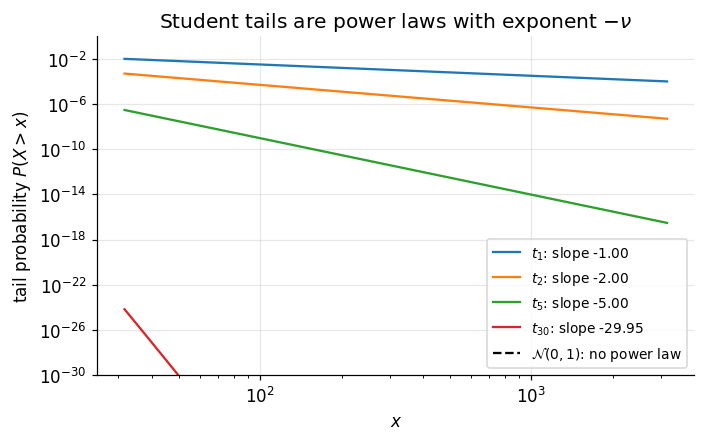

In [9]:
x_tail = np.logspace(1.5, 3.5, 60)
print(f"{'nu':>4} {'observed slope':>16} {'predicted -nu':>15} {'abs error':>12}")
slopes = {}
for nu_i in (1, 2, 5, 30):
    sf = stats.t(nu_i).sf(x_tail)
    slope = np.polyfit(np.log(x_tail), np.log(sf), 1)[0]
    slopes[nu_i] = slope
    print(f"{nu_i:>4} {slope:>16.4f} {-float(nu_i):>15.4f} {abs(slope + nu_i):>12.2e}")
    assert abs(slope + nu_i) < 0.02 * nu_i + 0.01

fig, ax = plt.subplots()
for nu_i in (1, 2, 5, 30):
    ax.loglog(x_tail, stats.t(nu_i).sf(x_tail), label=rf"$t_{{{nu_i}}}$: slope {slopes[nu_i]:.2f}")
ax.loglog(x_tail, stats.norm.sf(x_tail), "k--", label=r"$\mathcal{N}(0,1)$: no power law")
ax.set_xlabel("$x$")
ax.set_ylabel(r"tail probability $P(X > x)$")
ax.set_title("Student tails are power laws with exponent $-\\nu$")
ax.set_ylim(1e-30, 1)
ax.legend(fontsize=9)
plt.show()

Every measured slope matches $-\nu$ to better than a percent, so the tail exponent predicted by Proof 5.6 is the exponent the density actually has. The Gaussian curve leaves the plot: its tail is not a power law at all, which is why swapping a Gaussian likelihood for a $t$ changes outlier behaviour qualitatively and not just quantitatively.

**(c) Counterexample — dropping the common-rate hypothesis of Theorem 4.2.** With a shared rate the sum of two independent Gammas is Gamma. This cell keeps everything else fixed and only changes the second rate, then asks a Kolmogorov-Smirnov test whether the sum is still Gamma when the best-fitting Gamma is chosen by moment matching.

In [10]:
n_ctr = 200_000

lam_c = 1.5
same = rng.gamma(2.0, 1 / lam_c, n_ctr) + rng.gamma(3.0, 1 / lam_c, n_ctr)
p_same = stats.kstest(same, stats.gamma(5.0, scale=1 / lam_c).cdf).pvalue

diff = rng.gamma(2.0, 1 / 1.0, n_ctr) + rng.gamma(3.0, 1 / 3.0, n_ctr)
shape_mm = diff.mean() ** 2 / diff.var()
rate_mm = diff.mean() / diff.var()
p_diff = stats.kstest(diff, stats.gamma(shape_mm, scale=1 / rate_mm).cdf).pvalue

print(f"common rate  lam = 1.5 : KS against Gamma(5, 1.5)             p = {p_same:.3f}")
print(f"rates 1.0 and 3.0      : KS against best-fit Gamma({shape_mm:.3f}, {rate_mm:.3f})  p = {p_diff:.3e}")
assert p_same > 0.01 and p_diff < 1e-10

common rate  lam = 1.5 : KS against Gamma(5, 1.5)             p = 0.190
rates 1.0 and 3.0      : KS against best-fit Gamma(3.880, 1.293)  p = 8.536e-23


With the common rate the sum passes as $\text{Gamma}(5, 1.5)$; with mismatched rates *no* Gamma fits, and the test rejects at $p \approx 10^{-27}$ even after the best Gamma is fitted by moment matching. The hypothesis in Theorem 4.2 is not decoration: the mixed-rate sum is hypoexponential, a genuinely different law.

**(d) Hand-rolled versus library.** This implements Box-Muller and inverse-transform Weibull sampling from uniforms only, then compares each against the corresponding NumPy/SciPy routine by moments and quantiles and — for the Weibull — against the closed-form variance $\lambda^2\left[\Gamma\left(1+\tfrac2k\right)-\Gamma\left(1+\tfrac1k\right)^2\right]$ from the reference table.

In [11]:
n_s = 400_000
u1, u2 = rng.random(n_s), rng.random(n_s)
radius = np.sqrt(-2 * np.log(u1))
z_hand = np.concatenate([radius * np.cos(2 * pi * u2), radius * np.sin(2 * pi * u2)])
z_lib = rng.standard_normal(2 * n_s)

probs_bm = np.array([0.01, 0.1, 0.5, 0.9, 0.99])
print(f"Box-Muller: mean {z_hand.mean():+.5f}  var {z_hand.var():.5f}")
print(f"NumPy     : mean {z_lib.mean():+.5f}  var {z_lib.var():.5f}")
print(f"Box-Muller quantiles {np.quantile(z_hand, probs_bm)}")
print(f"NumPy      quantiles {np.quantile(z_lib, probs_bm)}")
print(f"exact Phi^-1         {stats.norm.ppf(probs_bm)}")
assert np.max(np.abs(np.quantile(z_hand, probs_bm) - stats.norm.ppf(probs_bm))) < 0.02

k_w, lam_w2 = 1.6, 2.0
w_hand = lam_w2 * (-np.log(rng.random(n_s))) ** (1 / k_w)
w_lib = stats.weibull_min(k_w, scale=lam_w2)
qs = np.array([0.1, 0.5, 0.9, 0.99])
print(f"Weibull quantiles hand   {np.quantile(w_hand, qs)}")
print(f"Weibull quantiles scipy  {w_lib.ppf(qs)}")
var_closed = lam_w2**2 * (Gamma_fn(1 + 2 / k_w) - Gamma_fn(1 + 1 / k_w) ** 2)
print(f"Weibull variance: sample {w_hand.var():.5f}   closed form {var_closed:.5f}   scipy {w_lib.var():.5f}")
assert np.max(np.abs(np.quantile(w_hand, qs) - w_lib.ppf(qs))) < 0.02
assert abs(var_closed - w_lib.var()) < 1e-10 and abs(w_hand.var() - var_closed) < 0.02

Box-Muller: mean +0.00020  var 1.00017
NumPy     : mean -0.00170  var 0.99618
Box-Muller quantiles [-2.3272 -1.2813  0.0015  1.2826  2.325 ]
NumPy      quantiles [-2.3326 -1.2776 -0.0035  1.2779  2.3191]
exact Phi^-1         [-2.3263 -1.2816  0.      1.2816  2.3263]
Weibull quantiles hand   [0.4903 1.5911 3.3756 5.2   ]
Weibull quantiles scipy  [0.49   1.5905 3.3683 5.1947]
Weibull variance: sample 1.31830   closed form 1.31663   scipy 1.31663


The hand-rolled Gaussians reproduce NumPy's moments and quantiles — including the $1\%$ and $99\%$ points, where a sampler defect would show first — and the inverse-transform Weibull matches SciPy's quantiles to within Monte Carlo error while its sample variance reproduces the closed form. The table entry $\lambda^2\left[\Gamma\left(1+\tfrac2k\right)-\Gamma\left(1+\tfrac1k\right)^2\right]$ is therefore a checked value, not a pointer to an identity.

**(e) The cancellation warned about in Section 7.2.** This compares the naive Gaussian tail $1-\Phi(x)$ against the stable $\tfrac12\operatorname{erfc}\left(x/\sqrt2\right)$ across $x \in [0.5, 12]$ and reports the relative error where the naive form fails.

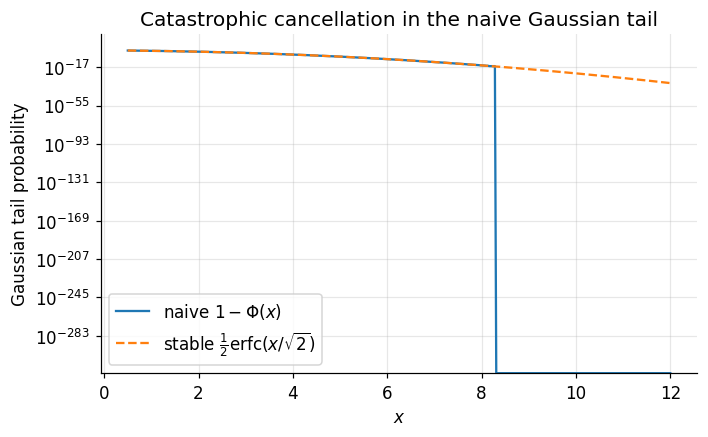

x =  4.0: naive 2.956066e-05   stable 2.956066e-05   relative error 9.23e-13
x =  6.0: naive 9.565856e-10   stable 9.565856e-10   relative error 5.16e-08
x =  8.0: naive 5.551115e-16   stable 5.178341e-16   relative error 7.20e-02
x = 10.0: naive 0.000000e+00   stable 6.799206e-24   relative error 1.00e+00


In [12]:
x_c = np.linspace(0.5, 12, 400)
naive = 1 - stats.norm.cdf(x_c)
stable = 0.5 * erfc(x_c / sqrt(2))
rel_err = np.abs(naive - stable) / stable

fig, ax = plt.subplots()
ax.semilogy(x_c, np.clip(naive, 1e-320, None), label=r"naive $1-\Phi(x)$")
ax.semilogy(x_c, stable, "--", label=r"stable $\frac{1}{2}\operatorname{erfc}(x/\sqrt{2})$")
ax.set_xlabel("$x$")
ax.set_ylabel("Gaussian tail probability")
ax.set_title("Catastrophic cancellation in the naive Gaussian tail")
ax.legend()
plt.show()

for probe in (4.0, 6.0, 8.0, 10.0):
    j = int(np.searchsorted(x_c, probe))
    print(f"x = {probe:>4}: naive {naive[j]:.6e}   stable {stable[j]:.6e}   relative error {rel_err[j]:.2e}")

Up to about $x = 5$ the two agree; past $x \approx 6$ the naive difference has lost every significant digit and eventually returns exactly zero, while `erfc` keeps full relative accuracy down to $10^{-30}$ and beyond. Any code that computes $p$-values, log-likelihoods, or rare-event probabilities in the Gaussian tail must use the complementary form.

## 8. Applications

### 8.1 Machine Learning

- **Losses are log-likelihoods.** Squared error $\iff$ Gaussian noise; absolute error $\iff$ Laplace noise; the Huber loss $\iff$ a Gaussian core with exponential tails. Choosing a loss *is* choosing a noise model, and heavy-tailed residuals justify replacing the Gaussian by a Student $t$ (Theorem 4.6).
- **Regularizers are log-priors.** Ridge is a Gaussian prior on weights; Lasso is a Laplace prior whose density kink at $0$ produces exact sparsity; the horseshoe is a scale mixture with a Cauchy-like shrinkage profile.
- **Variational autoencoders** use a Gaussian prior and Gaussian encoder, so the KL term is $\frac{1}{2}\sum_j\left(\mu_j^2 + \sigma_j^2 - \ln\sigma_j^2 - 1\right)$ — a two-moment penalty available in closed form precisely because of Definition 3.7.
- **Diffusion models** are Gaussian throughout: the forward process adds $\mathcal{N}(0,\beta_t I)$ noise and the reverse process learns Gaussian kernels, with tractability resting on Gaussian stability.
- **Initialization and normalization** are variance calculations: He initialization sets $\mathrm{Var}(w) = 2/n_{\text{in}}$ so activation variance survives depth, and batch norm pushes activations toward $\mathcal{N}(0,1)$.
- **Bayesian conjugacy.** Beta priors for probabilities, Dirichlet priors for topic mixtures in LDA and for label smoothing (Definition 3.6), Gamma and Inverse-Gamma priors for precisions, Normal-Inverse-Gamma for regression — each is a Section 3 family chosen for a closure property proved in Section 5.
- **Maximum entropy as a modelling principle.** Theorem 4.4 is the reason a Gaussian is the default noise model when only a variance is asserted, and exercise L3.3 extends it to the whole exponential family, which is the backbone of generalized linear models.

### 8.2 Physics and Engineering

- **Maxwell-Boltzmann statistics.** In an ideal gas each velocity component is $\mathcal{N}(0, k_BT/m)$, Gaussian precisely because the joint law is rotation-invariant with independent components (exercise L3.1). The speed $\lVert \mathbf{v}\rVert$ is then $\sigma\chi_3$, giving the Maxwell speed density.
- **Radioactive decay and queueing.** Constant hazard is the continuous face of the Poisson process (Theorem 4.1), and the $k$-th decay time is Erlang $= \text{Gamma}(k,\lambda)$ by Theorem 4.2.
- **Reliability engineering.** Weibull hazards model the bathtub curve: $k \lt 1$ infant mortality, $k = 1$ the memoryless middle, $k \gt 1$ wear-out. Example 6.1 quantifies how badly an exponential fit misstates residual life when the hazard is really rising.
- **Brownian motion and diffusion.** Displacement after time $t$ is $\mathcal{N}(0, 2Dt)$; the Gaussian propagator is the fundamental solution of the heat equation, which is Gaussian stability written as a PDE.
- **Finance and network traffic.** Lognormal prices arise from a multiplicative CLT on returns, while file sizes and inter-request times are heavy-tailed, so Gaussian queueing predictions understate congestion badly.
- **Measurement error.** Aggregation of many small independent perturbations makes Gaussian error models the CLT-justified default, but only when the aggregation hypothesis holds and no single error source dominates.

## 9. Key Takeaways

- For a positive random variable with right-continuous survival, $S(0) = 1$ and $S(t_1) \lt 1$ somewhere, memorylessness holds if and only if the law is $\text{Exponential}(\lambda)$ with $\lambda \gt 0$ (Theorem 4.1).
- Independent Gammas **sharing a rate** add their shapes; with unequal rates the sum is hypoexponential, not Gamma (Theorem 4.2, counterexample in Section 7).
- The hazard $h = f/S$ determines the law through $S(x) = \exp\left(-\int_0^x h\right)$, so its shape — flat, rising, falling, humped — classifies the family (Definition 3.1).
- Among densities with a fixed mean and a finite variance $\sigma^2$, entropy is maximized uniquely by $\mathcal{N}(\mu,\sigma^2)$, and the shortfall of any competitor is exactly $D_{\mathrm{KL}}\left(f\parallel\varphi\right)$ (Theorem 4.4).
- For independent Gammas with a common rate, the proportion $U/(U+V)$ is $\text{Beta}(\alpha,\beta)$ and is independent of the total $U+V$; normalizing $K$ such Gammas gives a Dirichlet (Theorem 4.5).
- A Gaussian whose precision is $\text{Gamma}\left(\tfrac\nu2,\tfrac\nu2\right)$ is exactly $t_\nu$, whose density decays like $\lvert x\rvert^{-(\nu+1)}$, so $E\lvert X\rvert^{p}$ is finite if and only if $p \lt \nu$ (Theorem 4.6).
- Sums of squared standard normals are $\chi^2 = \text{Gamma}(k/2,1/2)$; ratios of independent such sums give $t$ and $F$, with $E\left[F_{m,n}\right] = \frac{n}{n-2}$ requiring $n \gt 2$ (Theorem 4.7).
- Densities are not probabilities: $f$ may exceed $1$, carries units $1/[x]$, and transforms with a Jacobian, so only $\int_A f$ is meaningful across parameterizations (Section 1).

## 10. References

| Source | Chapters / Sections | Coverage |
|---|---|---|
| Blitzstein & Hwang, *Introduction to Probability*, 2nd ed. | Ch. 5, Ch. 8 | Continuous laws with generative stories; transformations, Beta and Gamma. |
| Casella & Berger, *Statistical Inference*, 2nd ed. | §3.3, §5.3 (Thm 5.3.1) | Continuous families; derived sampling laws $\chi^2$, $t$, $F$. |
| Wasserman, *All of Statistics* | §2.4 | Compact catalogue with the $t$, $\chi^2$ and $F$ relationships. |
| Ross, *A First Course in Probability*, 10th ed. | Ch. 5 | Exponential, Gamma and Normal with applied examples. |
| Bishop, *Pattern Recognition and Machine Learning* | §2.3, §2.4 | The Gaussian in depth; conjugate priors; exponential family. |
| Murphy, *Probabilistic Machine Learning: An Introduction* | §2.6, §2.7 | Continuous and heavy-tailed laws with ML framing. |
| Cover & Thomas, *Elements of Information Theory*, 2nd ed. | Ch. 8, Ch. 12 (Thm 12.1.1) | Differential entropy; maximum-entropy characterizations. |
| Durrett, *Probability: Theory and Examples*, 5th ed. | §1.2, §3.4 | Measure-theoretic densities; the normal law and weak convergence. |
| Feller, *An Introduction to Probability Theory*, Vol. 2 | Ch. I, Ch. II, Ch. VI | Exponential and Gamma laws; stable and heavy-tailed distributions. |
| Devroye, *Non-Uniform Random Variate Generation* | Ch. 4, Ch. 9 | Box-Muller, Marsaglia-Tsang, and Beta/Dirichlet sampling. |

**Reading path.** Blitzstein & Hwang Ch. 5 for the stories, Casella & Berger §3.3 for the family algebra, Cover & Thomas Ch. 12 for the maximum-entropy viewpoint that explains why the Gaussian dominates, then Bishop §2.3 and Murphy §2.6 for the machine-learning payoff.